# Rydberg sensitivity of the hydrogen SE populations

How much does swapping the Rydberg constant from the infinite-mass value to the
measured H ionization move the statistical-equilibrium (SE) level populations?

$$R_\infty = 109737.316\ \mathrm{cm^{-1}}\ \text{(Bohr, infinite nuclear mass)}
  \quad\longrightarrow\quad
  R_H = 109678.758\ \mathrm{cm^{-1}}\ \text{(measured, NIST / RH)}.$$

The fractional drop is tiny, $\Delta R / R_\infty \approx 5.34\times10^{-4}$
($\Delta\chi \approx 7.4\times10^{-3}$ eV in the ionization energy), but it
propagates non-uniformly through the SE solve. This notebook maps the effect
over $T_e \in \{7000, 10000, 50000\}$ K and
$N_e \in \{10^8, \dots, 10^{13}\}\ \mathrm{cm^{-3}}$.

This notebook is **generated** from `build_notebook.py` in this folder.
Re-run the script after any change to the SE / Atomic / Constants APIs.


## How the Rydberg enters the SE solve

`SELib.cal_SE_with_Ne_Te_` returns the normalized population vector `n_SE`
(sums to 1; `n_SE[0]` = neutral ground $n_1$, `n_SE[-1]` = ionization fraction
$n_p/N_\mathrm{tot}$). The analysis tracks four indices throughout — the first
three bound levels $n_1, n_2, n_3$ and the ionization fraction
$n_p/N_\mathrm{tot}$. The Rydberg reaches them through **two channels**:

| channel | where | mechanism |
|---|---|---|
| **level energies** | `atom.Level["erg"]` in the Saha/Boltzmann factors | $\exp(-E/kT_e)$ — thermodynamic balance |
| **rate coefficients** | `Hydrogen.CE_rate_coe_`, `CI_rate_coe_`, PI cross-sections | $E_{ij} = E_\mathrm{Ry}\,(1/n_i^2 - 1/n_j^2)$ — kinetic rates |

The *theoretical* hydrogen atom rebuilds both from the one constant
`Constants.E_Rydberg_H_`, so a single monkeypatch toggles the whole solve
self-consistently (numba JIT is off, every lookup is qualified `CST.E_Rydberg_H_`).

**Analytic expectation (Saha).** Bound level $n$ binds to the continuum by
$\chi/n^2$, so in the ionized regime its population scales as
$n_n \propto e^{+\chi/(n^2 kT_e)}$, giving

$$\frac{\Delta n_n}{n_n} \approx -\frac{\Delta\chi}{n^2\,kT_e},
  \qquad
  \frac{\Delta(\text{ion frac})}{\text{ion frac}} \approx +\frac{\Delta\chi}{kT_e}
  \ \ (\text{neutral regime}).$$

The ground-state amplitude is $\Delta\chi/kT_e = \{1.2\%,\, 0.84\%,\, 0.17\%\}$ at
$T_e=\{7000, 10000, 50000\}$ K, falling as $1/n^2$ up the series. The effect
therefore **shrinks with $T_e$ and up the series**, and along $N_e$ it is largest
wherever the *minority* species sits deepest in the Boltzmann tail.

A clean **collisional-radiative** field is used (`se_params.Tr = Te`, i.e. a
Planck driver at $T_e$), so the high-$N_e$ limit reduces to exact LTE and the
numbers can be checked against the analytic Saha estimate above.


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import spectra.Constants as CST
from spectra.Atomic import Hydrogen
from spectra.Function.SEquil import SELib
from spectra.Struct import Atmosphere, Atom, Radiation
from spectra.Struct.Container.SEquil import SE_Params_Container

# the patch only propagates if the rate modules share this Constants object
assert Hydrogen.CST is CST, "Rydberg monkeypatch would not reach the rate functions"

NLEVEL = 11          # n=1..10 bound + continuum (matches data/atom/H/H.Level)
VT = 5.0e5           # microturbulent velocity [cm/s]; affects only line widths

R_INF_CM = 109737.316   # R_inf, infinite nuclear mass (Bohr)         [cm^-1]
R_H_CM = 109678.758     # measured H ionization (NIST / RH)           [cm^-1]

TE_LIST = [7000.0, 10000.0, 50000.0]                       # [K]
NE_LIST = [1e8, 1e9, 1e10, 1e11, 1e12, 1e13]               # [cm^-3]

_R_MEASURED_ERG = CST.E_Rydberg_H_   # restore at the end


# Patch the module-level Rydberg energy [erg]. JIT is off, so every qualified
# CST.E_Rydberg_H_ lookup in the rate functions and in the theoretical-atom
# builder picks this up at call time.
def set_rydberg(R_cm):
    CST.E_Rydberg_H_ = R_cm * CST.c_ * CST.h_


# Theoretical H atom + SE solve at one (Rydberg, Te, Ne). Both the level energies
# and the rate coefficients track R_cm. Returns the normalized population vector.
def solve_SE(R_cm, Te, Ne):
    set_rydberg(R_cm)
    atom = Atom.init_theoretical_hydrogen_atom_(nLevel=NLEVEL)
    atmos = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd_obs=0.0, Vd_sun=0.0, Vt=VT)
    radiation = Radiation.init_Radiation_()
    se, _ = SELib.cal_SE_with_Ne_Te_(
        atom, atmos, radiation, None, se_params=SE_Params_Container(Tr=Te)
    )
    return se.n_SE


## Compute the grid

$2 \times 3 \times 6 = 36$ SE solves (sub-second total).


In [2]:
shape = (len(TE_LIST), len(NE_LIST))
n_inf = np.empty(shape, dtype=object)   # R_inf populations per cell
n_meas = np.empty(shape, dtype=object)  # measured-R populations per cell

for i, Te in enumerate(TE_LIST):
    for j, Ne in enumerate(NE_LIST):
        n_inf[i, j] = solve_SE(R_INF_CM, Te, Ne)
        n_meas[i, j] = solve_SE(R_H_CM, Te, Ne)

set_rydberg(R_H_CM)  # leave the module at the production (measured) value
assert abs(CST.E_Rydberg_H_ - _R_MEASURED_ERG) / _R_MEASURED_ERG < 1e-12


# (measured - R_inf) / R_inf of one level's population, over the grid.
def rel_change(level_index):
    out = np.zeros(shape)
    for i in range(shape[0]):
        for j in range(shape[1]):
            a, b = n_inf[i, j][level_index], n_meas[i, j][level_index]
            out[i, j] = (b - a) / a if a != 0.0 else 0.0
    return out


d_n1 = rel_change(0)       # neutral ground       n_1
d_n2 = rel_change(1)       # first excited        n_2
d_n3 = rel_change(2)       # second excited       n_3
d_ion = rel_change(-1)     # ionization fraction  n_p / N_tot
print("ionization fraction (measured R_H), grid [Te x Ne]:")
print(np.array([[n_meas[i, j][-1] for j in range(shape[1])] for i in range(shape[0])]))


ionization fraction (measured R_H), grid [Te x Ne]:
[[0.99956476 0.99566464 0.958276   0.69672307 0.18690698 0.02247739]
 [0.99999971 0.99999705 0.99997052 0.99970535 0.9970627  0.97139245]
 [1.         1.         1.         1.         0.99999998 0.99999984]]


## Summary table

Relative population change $(n_{R_H} - n_{R_\infty})/n_{R_\infty}$ per cell.


In [3]:
def fmt_row(name, arr, i):
    return f"  {name:<10}" + "".join(f"{arr[i, j]:+11.2e}" for j in range(shape[1]))


hdr = "Ne [cm^-3]:" + "".join(f"{ne:>11.0e}" for ne in NE_LIST)
for i, Te in enumerate(TE_LIST):
    print(f"\nTe = {Te:.0f} K")
    print(hdr)
    print(fmt_row("d n=1", d_n1, i))
    print(fmt_row("d n=2", d_n2, i))
    print(fmt_row("d n=3", d_n3, i))
    print(fmt_row("d ion", d_ion, i))



Te = 7000 K
Ne [cm^-3]:      1e+08      1e+09      1e+10      1e+11      1e+12      1e+13
  d n=1       -1.20e-02  -1.19e-02  -1.15e-02  -8.34e-03  -2.24e-03  -2.69e-04
  d n=2       -3.00e-03  -2.95e-03  -2.50e-03  +6.57e-04  +6.81e-03  +8.80e-03
  d n=3       -1.33e-03  -1.28e-03  -8.32e-04  +2.33e-03  +8.50e-03  +1.05e-02
  d ion       +5.27e-06  +5.25e-05  +5.05e-04  +3.67e-03  +9.84e-03  +1.18e-02

Te = 10000 K
Ne [cm^-3]:      1e+08      1e+09      1e+10      1e+11      1e+12      1e+13
  d n=1       -8.39e-03  -8.39e-03  -8.39e-03  -8.39e-03  -8.36e-03  -8.15e-03
  d n=2       -2.10e-03  -2.10e-03  -2.10e-03  -2.10e-03  -2.08e-03  -1.86e-03
  d n=3       -9.36e-04  -9.36e-04  -9.35e-04  -9.33e-04  -9.10e-04  -6.93e-04
  d ion       +2.49e-09  +2.49e-08  +2.49e-07  +2.49e-06  +2.48e-05  +2.42e-04

Te = 50000 K
Ne [cm^-3]:      1e+08      1e+09      1e+10      1e+11      1e+12      1e+13
  d n=1       -1.68e-03  -1.68e-03  -1.68e-03  -1.68e-03  -1.68e-03  -1.68e-03
  d n=2       

## Heatmaps — $T_e \times N_e$

Diverging colour scale centred at zero; annotations are the relative change.


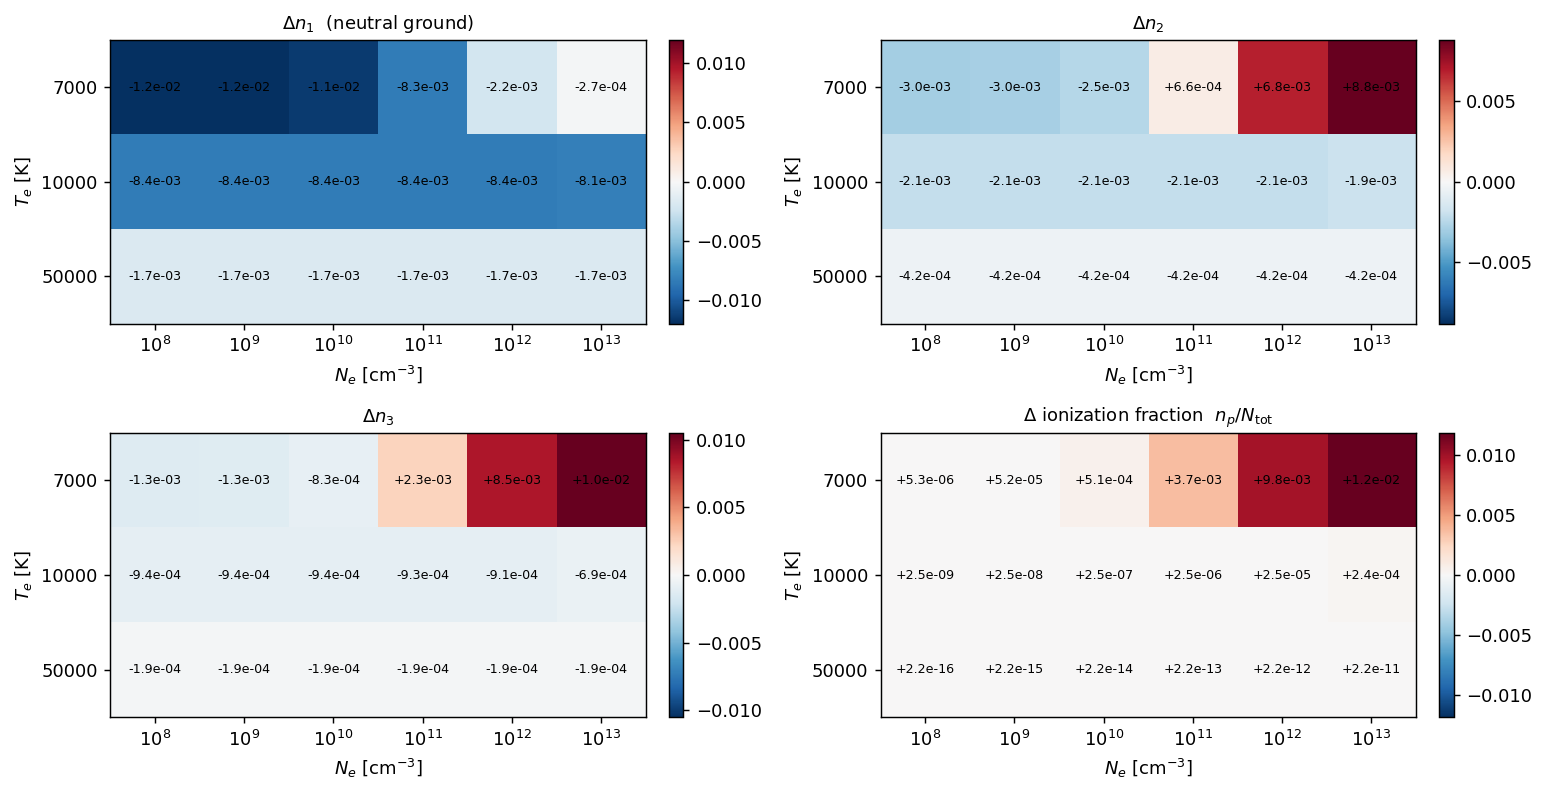

In [4]:
def heatmap(ax, data, title):
    vmax = np.abs(data).max()
    im = ax.imshow(data, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(NE_LIST)))
    ax.set_xticklabels([f"$10^{{{int(np.log10(ne))}}}$" for ne in NE_LIST])
    ax.set_yticks(range(len(TE_LIST)))
    ax.set_yticklabels([f"{int(te)}" for te in TE_LIST])
    ax.set_xlabel(r"$N_e$ [cm$^{-3}$]")
    ax.set_ylabel(r"$T_e$ [K]")
    ax.set_title(title, fontsize=10)
    for i in range(len(TE_LIST)):
        for j in range(len(NE_LIST)):
            ax.text(j, i, f"{data[i, j]:+.1e}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


fig, axes = plt.subplots(2, 2, figsize=(12, 6.2), dpi=130)
heatmap(axes[0, 0], d_n1, r"$\Delta n_1$  (neutral ground)")
heatmap(axes[0, 1], d_n2, r"$\Delta n_2$")
heatmap(axes[1, 0], d_n3, r"$\Delta n_3$")
heatmap(axes[1, 1], d_ion, r"$\Delta$ ionization fraction  $n_p/N_\mathrm{tot}$")
plt.tight_layout()
plt.show()


**Reading the maps.**

- **Bound levels $n_1, n_2, n_3$** move by a nearly $N_e$-independent amount
  that tracks $-\Delta\chi/kT_e$ in the ionized regime and shrinks down each
  column as $T_e$ rises. $n_2$ and $n_3$ depart from the $n_1$ value toward
  high $N_e$/low $T_e$, where they couple to the rising ionization.
- **Ionization fraction** moves most at **low $T_e$ / high $N_e$** — the
  bottom-right of its panel, where H is mostly neutral and the ions sit in the
  Boltzmann tail. Where H is already fully ionized (high $T_e$, low $N_e$) the
  fraction saturates at 1 and is insensitive.


## Per-level change at one representative cell


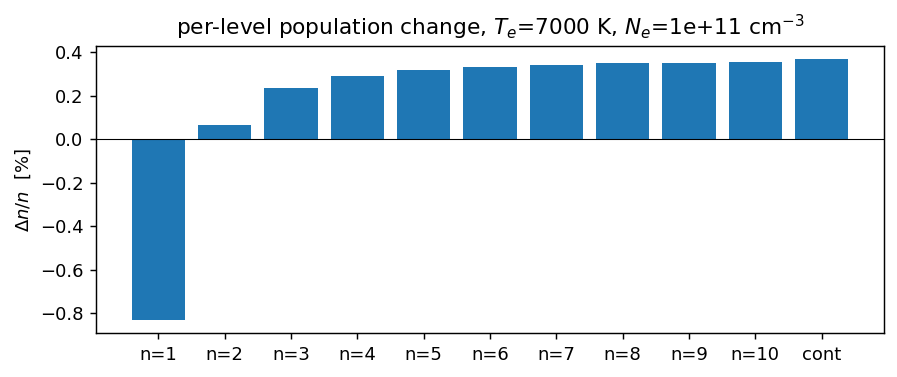

In [5]:
i_rep, j_rep = 0, 3   # Te=7000 K, Ne=1e11 cm^-3
a, b = n_inf[i_rep, j_rep], n_meas[i_rep, j_rep]
levels = np.arange(NLEVEL)
rel = np.where(a != 0.0, (b - a) / a, 0.0)

fig, ax = plt.subplots(1, 1, figsize=(7, 3), dpi=130)
ax.bar(levels, rel * 100.0, color="C0")
ax.axhline(0.0, color="k", lw=0.6)
ax.set_xticks(levels)
ax.set_xticklabels([f"n={n + 1}" for n in range(NLEVEL - 1)] + ["cont"])
ax.set_ylabel(r"$\Delta n / n$  [%]")
ax.set_title(
    rf"per-level population change, $T_e$={TE_LIST[i_rep]:.0f} K, "
    rf"$N_e$={NE_LIST[j_rep]:.0e} cm$^{{-3}}$"
)
plt.tight_layout()
plt.show()


## Validation against the analytic Saha estimate

Bound level $n$ binds to the continuum by $\chi/n^2$, so in the ionized regime
its Saha sensitivity is $-\Delta\chi/(n^2 kT_e)$ — a $1/n^2$ reduction down the
series. Compare the lowest-$N_e$ (most ionized) cells against the closed form.


In [6]:
dchi_erg = (R_INF_CM - R_H_CM) * CST.c_ * CST.h_   # ionization-energy drop [erg], > 0
# level n binds to the continuum by chi/n^2, so its Saha sensitivity is
# -d(chi/n^2)/kTe = -dchi/(n^2 kTe): the 1/n^2 law checked below (most-ionized
# column, Ne=1e8).
print(f"{'Te [K]':>8} {'n':>3} {'-dchi/(n^2 kTe)':>18} {'d n_n (Ne=1e8)':>18}")
for i, Te in enumerate(TE_LIST):
    for n, d in ((1, d_n1), (2, d_n2), (3, d_n3)):
        analytic = -dchi_erg / (n**2 * CST.k_ * Te)
        print(f"{Te:8.0f} {n:>3} {analytic:18.2e} {d[i, 0]:18.2e}")
    print()


  Te [K]   n    -dchi/(n^2 kTe)     d n_n (Ne=1e8)
    7000   1          -1.20e-02          -1.20e-02
    7000   2          -3.01e-03          -3.00e-03
    7000   3          -1.34e-03          -1.33e-03

   10000   1          -8.43e-03          -8.39e-03
   10000   2          -2.11e-03          -2.10e-03
   10000   3          -9.36e-04          -9.36e-04

   50000   1          -1.69e-03          -1.68e-03
   50000   2          -4.21e-04          -4.21e-04
   50000   3          -1.87e-04          -1.88e-04



**Verification.** Each bound level matches $-\Delta\chi/(n^2 kT_e)$ in the
most-ionized cells (at 7000 K: $n_1=-1.2\%$, $n_2=-0.30\%\approx-1.2\%/4$,
$n_3=-0.13\%\approx-1.2\%/9$), confirming the effect is the Saha shift of each
level's binding energy $\chi/n^2$. The $1/(n^2 T_e)$ scaling explains why the
impact is largest for the ground state at low $T_e$ (~1%) and falls off both up
the series and with temperature (~0.2% at 50000 K).

## Takeaway

Swapping $R_\infty \to R_H$ ($\sim$0.05% in the constant) shifts the hydrogen SE
populations by at most $\sim$1% (collisional-excitation / -ionization rates and
the neutral fraction at low $T_e$), and far less at high $T_e$. The change is a
clean $\Delta\chi/kT_e$ Saha effect, concentrated wherever the minority species
sits deepest in the Boltzmann tail — consistent with the small
golden-value shifts seen when the constant was standardized.
